<a href="https://colab.research.google.com/github/alimoorreza/CS167-fall26-notes/blob/main/Day12_Decision_Tree_using_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS167: Day12
## Decision Tree using Scikit Learn

#### CS167: Machine Learning, Fall 2026


📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs167_fall26/cs167_syllabus_fall26.pdf)

# Overview of the Scikit Learn 'Algorithm':

When working in Scikit Learn (`sklearn`), there is a general pattern that we can follow to implement any supported machine learning algorithm.

It goes like this:
1. Load your data using `pd.read_csv()`
2. Split your data `train_test_split()`
3. Create your classifier/regressor object
4. Call `fit()` to train your model
5. Call `predict()` to get predictions
6. Call a metric function to measure the performance of your model.

## All together, it looks something like this:

In [1]:
# Mount your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#classic scikit-learn algorithm

#0. import libraries
import sklearn
import pandas
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import neighbors

#1. load data
path = '/content/drive/MyDrive/cs167_fall26/datasets/irisData.csv'
iris_data = pandas.read_csv(path)

#2. split data
predictors = ['sepal length', 'sepal width', 'petal length', 'petal width']
target = "species"
train_data, test_data, train_sln, test_sln = train_test_split(iris_data[predictors], iris_data[target], test_size = 0.2, random_state=41)

#3. Create classifier/regressor object (change these parameters for Exercise #1)
dt = tree.DecisionTreeClassifier()

#4. Call fit (to train the classification/regression model)
dt.fit(train_data,train_sln)

#5. Call predict to generate predictions
iris_predictions = dt.predict(test_data)

#6. Call a metric function to measure performance
print("Accuracy:", metrics.accuracy_score(test_sln,iris_predictions))

# Show the acutal and predicted (this isn't necessary, but may help catch bugs)
print("___PREDICTED___ \t  ___ACTUAL___")
for i in range(len(test_sln)):
    print(iris_predictions[i],"\t\t", test_sln.iloc[i])

print("-------------------------------------------------------")
#print out a confusion matrix
iris_labels= ["Iris-setosa", "Iris-versicolor","Iris-virginica"]
conf_mat = metrics.confusion_matrix(test_sln, iris_predictions, labels=iris_labels)
print(pandas.DataFrame(conf_mat,index = iris_labels, columns = iris_labels))


Accuracy: 0.9
___PREDICTED___ 	  ___ACTUAL___
Iris-versicolor 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-virginica 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versic

# Now, let's go through step-by-step:

## Step 1: Import libraries and load your data

We should be pretty familiar with this one.
- mount your drive
- import any relevant libraires
- use `pd.read_csv()` to load in your dataset

In [44]:
#0. import libraries
import sklearn
import pandas
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn import neighbors

#1. load data
path = '/content/drive/MyDrive/cs167_fall26/datasets/irisData.csv'
iris_data = pandas.read_csv(path)
iris_data.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Step 2: Split Data

Cross-Validation is an important step in machine learning which enables us to evaluate our models. To do this, we need to split our data into `train_data` and `test_data`.
<div>
<img src="https://analytics.drake.edu/~reza/teaching/cs167_sp25/notes/images/day04_cross_validation.png" width=600/>
</div>

Sklearn takes this a step futher and splits the data up into 4 pieces:

<div>
<img src="https://analytics.drake.edu/~reza/teaching/cs167_sp25/notes/images/day06_traintestsplit.png" width=600/>
</div>

- `train_data`: holds the predictor variables of the training set
- `train_sln`: holds the target variable of the training set
- `test_data`: holds the predictor variables of the testing set
- `test_sln`: holds the target varibles of the testing set

## Step 2: Splitting Data (the code)
> - [sklearn-train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [6]:
#2. split data
predictors = ['sepal length', 'sepal width','petal length', 'petal width']
#predictors = data.columns.drop('species')
target = "species"
train_data, test_data, train_labels, test_labels = train_test_split(iris_data[predictors], iris_data[target], test_size = 0.2, random_state=41)

In [7]:
# take a look at the data... make sure you understand what split of data is stored in each
print('train_data shape: ',train_data.shape)
print('test_data shape: ',test_data.shape)
print('train_sln shape: ',train_sln.shape)
print('test_sln shape: ',test_sln.shape)

train_data.head()

train_data shape:  (120, 4)
test_data shape:  (30, 4)
train_sln shape:  (120,)
test_sln shape:  (30,)


,sepal length,sepal width,petal length,petal width
79,5.7,2.6,3.5,1.0
54,6.5,2.8,4.6,1.5
106,4.9,2.5,4.5,1.7
90,5.5,2.6,4.4,1.2
145,6.7,3.0,5.2,2.3


## Step 3: Create classifier/regressor object

The syntax/wording for this is going to come directly from the `sklearn` documentation.
- [Scikit Learn Decision Tree documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

The name of the model will change based on whether you are doing a __classification__ or __regression__.
- generally in the name:
    - `tree.DecicionTreeClassifier()`
    - `tree.DecisionTreeRegressor()`

In [8]:
#3. Create classifier/regressor object (change these parameters for Exercise #1)
from sklearn import tree
dt = tree.DecisionTreeClassifier()

## Step 4: Call `fit()` to train the model

Each machine learning model has a training process associated with it. Scikit learn makes it easy to train whatever model you choose by simply calling `fit()` on that model.

We generally pass two things into `fit()`:
- `train_data`: the predictor variables we want to train our model on
- `train_sln`: the labels for each training examples


In [9]:
dt.fit(train_data, train_labels)

DecisionTreeClassifier()

## Step 5: Call `predict()` to get predictions

After our model is trained, it's time to run our testing data through our model and see what the model predicts.

Scikit learn lets us do this in one line:
- we're saving what the function is returning as `predictions`
- passing in `test_data`, which is the data without labels that was not included in training

In [10]:
predictions = dt.predict(test_data)
print('predictions.shape: ', predictions.shape)
print(predictions)

predictions.shape:  (30,)
['Iris-versicolor' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor']


In [11]:
print(test_labels)

119     Iris-virginica
128     Iris-virginica
135     Iris-virginica
91     Iris-versicolor
112     Iris-virginica
71     Iris-versicolor
123     Iris-virginica
85     Iris-versicolor
147     Iris-virginica
143     Iris-virginica
127     Iris-virginica
39         Iris-setosa
38         Iris-setosa
93     Iris-versicolor
23         Iris-setosa
133     Iris-virginica
30         Iris-setosa
83     Iris-versicolor
37         Iris-setosa
41         Iris-setosa
81     Iris-versicolor
120     Iris-virginica
43         Iris-setosa
2          Iris-setosa
64     Iris-versicolor
62     Iris-versicolor
56     Iris-versicolor
67     Iris-versicolor
49         Iris-setosa
63     Iris-versicolor
Name: species, dtype: object


# Step 6: Evaluate the Model

Now that we have some predictions, we need to check to see how close we were by passing our predictions and the actual correct answers into a metric function.

| **Type of ML** | **Metric**                | **Description**                                                                                       | Scikit Learn                                                                                                                                                            |
|----------------|---------------------------|:-------------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Classification | Accuracy                  | Number correct examples divided by total number                                                       | [`sklearn.metrics.accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)                                               |
| Classification | Confusion Matrix          | Detailed table of where our model got confused.                                                       | [`sklearn.metrics.confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)          |
| Regression     | Mean Absolute Error (MAE) | The average absolute distance from the target variable                                                | [`sklearn.metrics.mean_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html#sklearn.metrics.mean_absolute_error) |
| Regression     | Mean Squared Error (MSE)  | The average squared distance from the target variable                                                 | [`sklearn.metrics.mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error)    |
| Regression     | $R^2$                     | 1: perfectly fit data 0: same performance as guessing the mean of the target variable -1: really bad. | [`sklearn.metrics.r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score)                                  |

Available metrics can be found in the sklearn documentation [[sklearn metrics]](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

In [12]:
#6. call a metric function to evaluate the model
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(test_labels, predictions)} ")

Accuracy: 0.9 


### Here's an example of displaying a confusion matrix:

Documentation link: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay


In [13]:
#print out a confusion matrix
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(test_labels, predictions)
print(conf_mat)

[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]


In [14]:
#displaying a confusion matrix
# option #1: text
import pandas
iris_labels= ["Iris-setosa", "Iris-versicolor","Iris-virginica"]

pd = pandas.DataFrame(conf_mat,index = iris_labels, columns = iris_labels)
pd.head()

,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,9,0,0
Iris-versicolor,0,10,1
Iris-virginica,0,2,8


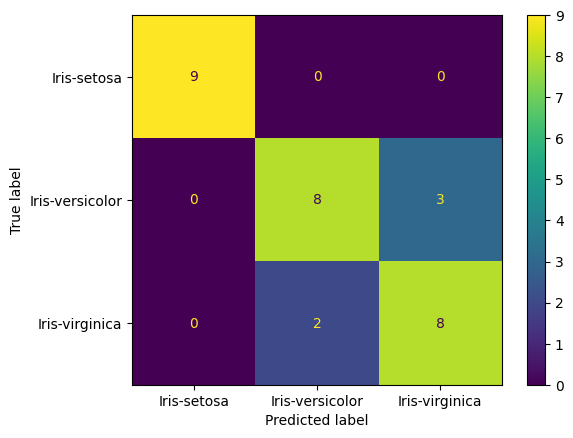

In [ ]:
# option #2: prettify
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
iris_labels= ["Iris-setosa", "Iris-versicolor","Iris-virginica"]
display_obj = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=iris_labels)
display_obj.plot()
plt.show()

## (Optional) Step 7: Print out the results to debug

Sometimes its helpful to take a closer look at your predictions. Here's some code to do just that:

In [15]:
# Show the acutal and predicted (this isn't necessary, but may help catch bugs)
print("___PREDICTED___ \t___ACTUAL___")
for i in range(len(test_sln)):
    print(predictions[i],"\t\t", test_labels.iloc[i])


___PREDICTED___ 	___ACTUAL___
Iris-versicolor 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-virginica 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-virginica 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-virginica 		 Iris-virginica
Iris-setosa 		 Iris-setosa
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-versicolor 		 Iris-versicolor
Iris-setosa 		 Iris-setosa
Iris-versicolor 		 Iris-versicolor


# 💬 Group Exercise #1:

Take a look at the [Decision Tree Classifier Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html):
- Experiment with different value of `random_state`
- Explore different parameters you could use in the `DecisionTreeClassifier`
- Can you improve the accuracy with `random_state=41`?
- What happens when you do this? Why?

# Plotting Decision Trees

You can use `matplotlib` to plot decision trees using the `sklearn.tree.plot_tree` method.

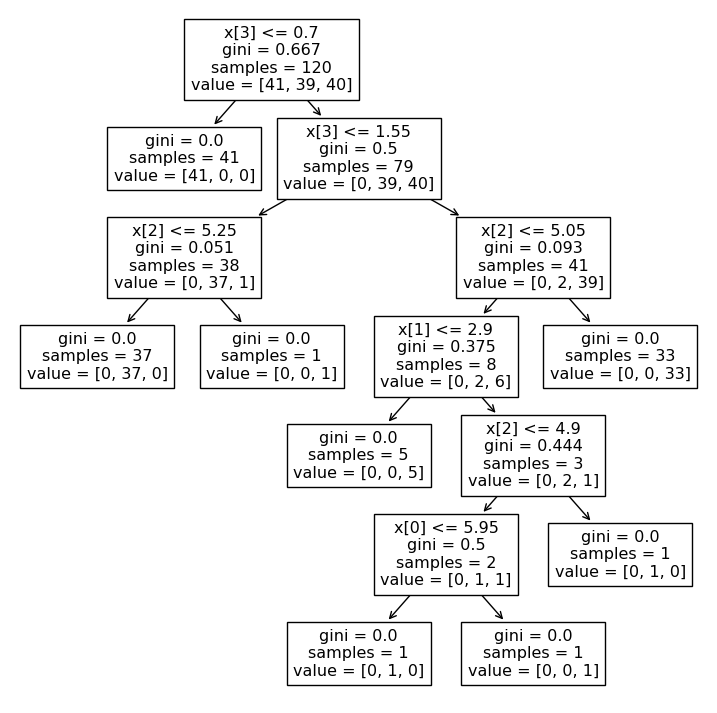

In [ ]:
# visualizing decision tree
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(9,9)) # Makes it so the graph isn't tiny
tree.plot_tree(dt);       #if you remove the ;, you'll get more information about the tree

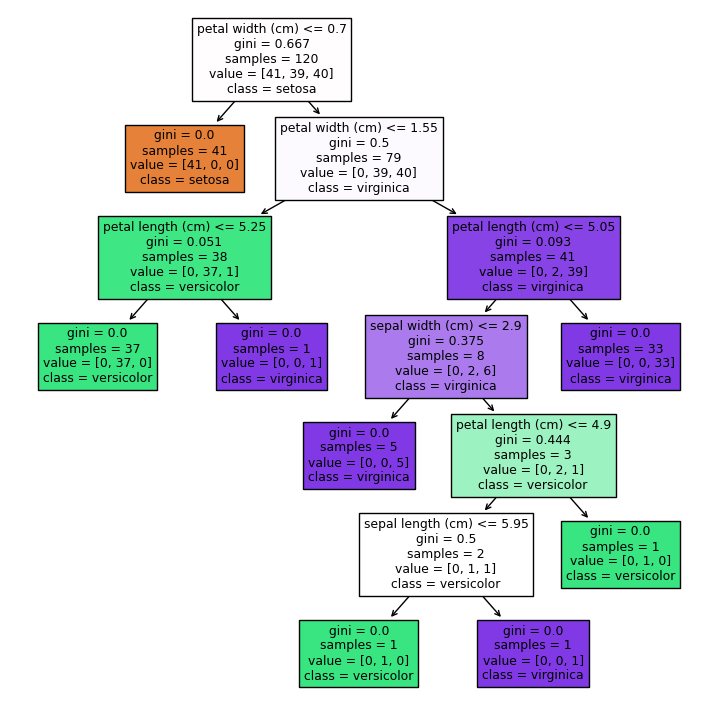

In [ ]:
#tweak paramters to make it pretty
import matplotlib.pyplot as plt
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(9,9))
#fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,3), dpi=300) # more tuned plot but the previous line should work

tree.plot_tree(dt, feature_names=fn, class_names=cn, filled=True)
plt.show()

In [ ]:
#including this to make the plot display during slide mode

## Another pretty Confusion Matrix

Text(0.5, 0, 'Predicted label')

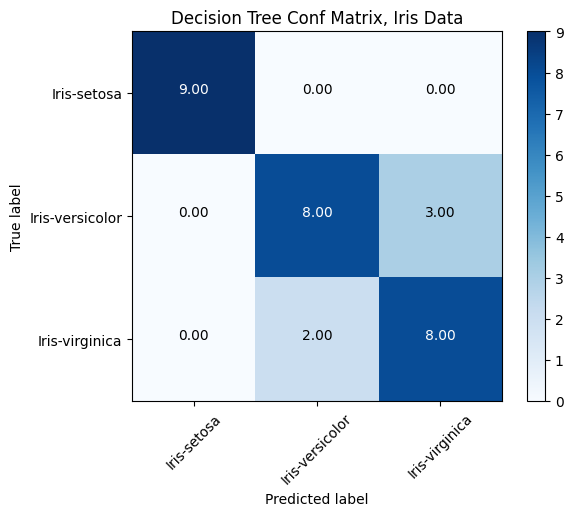

In [ ]:
# a pretty confusion matrix
import itertools

cm=metrics.confusion_matrix(test_sln,predictions)
plt.imshow(cm, interpolation='nearest',cmap=plt.cm.Blues)
plt.title('Decision Tree Conf Matrix, Iris Data')
plt.colorbar()
plt.xticks([0,1,2], dt.classes_,rotation=45)
plt.yticks([0,1,2], dt.classes_)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')

# 💬 Group Exercise #2:

With the aid of the [`sklearn.tree.DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) documentation, try the following:
- Create a decision tree with an early stopping parameter (hint: think about `max_depth` parameter)
- Visualize your trees to see if it is working right.
- Look at your performance metrics to see how it changes performance.
- Determine which of the features (petal length, sepal length, etc) were the most important.How does it determine these numbers?

accuracy: 0.9


# 💬 Group Exercise #3:
## Let's try regression now:

Using the `vehicles.csv` dataset, let's try out sklearn with regression:
- load the data, get the right subset
- set predictors and target variables
- use `train_test_split()` to split the data

In [42]:
# load in the vehicles.csv data for scikit learn
import pandas
import numpy

# load data, get the right subset
path = '/content/drive/MyDrive/cs167_fall26/datasets/vehicles.csv'
data = pandas.read_csv(path, low_memory=False)
gas_vehicles = data[data['fuelType']=='Regular'][['year', 'cylinders', 'displ', 'comb08']]
gas_vehicles.dropna(inplace=True)

# set the predictor variables and target variable
predictors= ['year', 'cylinders', 'displ']
target= 'comb08'

total_test_samples = 700
test_ratio = 500/gas_vehicles.shape[0]

# use train_test_split() to split the data
train_data, test_data, train_labels, test_labels = train_test_split(gas_vehicles[predictors],
                                                              gas_vehicles[target],
                                                              test_size = test_ratio,
                                                              random_state=41)
'''
train_data, test_data, train_labels, test_labels = train_test_split(gas_vehicles[predictors],
                                                              gas_vehicles[target],
                                                              test_size = 700,
                                                              random_state=41)
'''
print(f"train split size={train_data.shape[0]} and test split size={test_data.shape[0]}")
print("\n")
train_data.head()

train split size=26360 and test split size=500




,year,cylinders,displ
23998,2012,6.0,4.0
28987,2016,4.0,2.4
38630,1990,4.0,2.3
37219,1989,4.0,2.2
30186,2017,4.0,2.5


And then we do the next steps:
- build our model using `tree.DecisionTreeRegressor()`
- fit our model using `fit()` and passing in `train_data` and `train_sln`
- get our predictions by calling `predict()`
- evaluate our predictions using `metrics.mean_squared_error()`, and `metrics.r2_score()`

In [ ]:
from sklearn import neighbors
# create our model

# fit (train) the model to the data

# use the trained model to get predictions from our test_data

# use a metric to see how good our predictions are
